# Доверительные интервалы: b-value в сейсмологии

**Постановка.** Закон Гутенберга–Рихтера: число землетрясений с магнитудой $\geq M$ убывает как $10^{-bM}$. Параметр $b$ (b-value) — ключевая характеристика сейсмического региона. Превышения магнитуд над порогом полноты каталога $M_c$ моделируются экспоненциальным распределением с параметром $\beta = b \ln 10$.

**Задачи.**
1. ОМП для $b$; асимптотические и точные доверительные интервалы, их сравнение.
2. Оценка порога полноты $M_c$: пример параметра, для которого асимптотика ОМП **не** нормальная, а симметричный «нормальный» интервал ломается.
3. Пуассоновская интенсивность потока событий.
4. Проверка фактического покрытия всех интервалов методом Монте-Карло.

## Данные и закон Гутенберга–Рихтера

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


In [12]:
from scipy import stats


In [13]:
# Загрузка каталога

df = pd.read_csv("../data/earthquakes.csv", parse_dates=["time"])

print("Событий:", len(df))
print(f"Период: {df.time.min()} — {df.time.max()}")
print(f"Магнитуды: {df.mag.min():.2f} — {df.mag.max():.2f}")
df.head()


Событий: 10894
Период: 2023-01-01 01:05:49.510656026 — 2023-12-31 21:05:03.929524451
Магнитуды: 1.00 — 4.78


,time,latitude,longitude,depth,mag
0,2023-01-01 01:05:49.510656026,34.8019,-121.9243,7.77,1.53
1,2023-01-01 01:18:10.935678826,33.1688,-119.9133,9.07,1.65
2,2023-01-01 02:14:23.463854559,37.0406,-116.3485,7.24,1.29
3,2023-01-01 02:21:45.313513770,32.6126,-118.8101,17.08,1.56
4,2023-01-01 03:23:25.729233272,35.1088,-117.9430,6.44,1.20


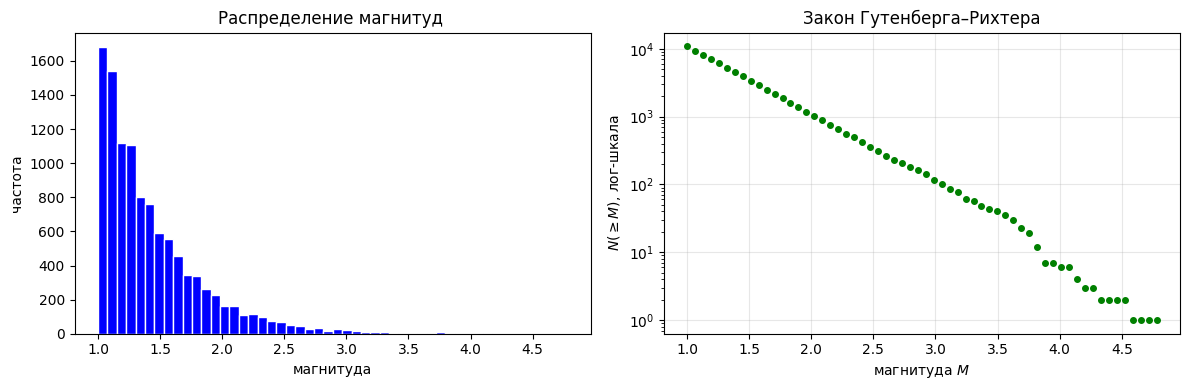

In [34]:
# Гистограмма магнитуд

mags = df.mag.values

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(mags, bins=50, color="blue", edgecolor="white")
ax[0].set_xlabel("магнитуда"); ax[0].set_ylabel("частота")
ax[0].set_title("Распределение магнитуд ")

# Кумулятивный закон ГР в полулог-шкале: log10 N(>=M) vs M  -> прямая с наклоном -b

m_grid = np.linspace(mags.min(), mags.max(), 60)
N_ge = [(mags >= m).sum() for m in m_grid]

ax[1].semilogy(m_grid, N_ge, "o", color="green", markersize=4)
ax[1].set_xlabel("магнитуда $M$"); ax[1].set_ylabel(r"$N(\geq M)$, лог-шкала")
ax[1].set_title("Закон Гутенберга–Рихтера")
ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


Прямая в полулогарифмической шкале подтверждает закон Гутенберга–Рихтера; излом слева от порога $M_c$ — неполнота каталога на малых магнитудах.

## ОМП для b-value

Для превышений $x_i = M_i - M_c \sim \mathrm{Exp}(\beta)$: $\hat\beta = 1/\bar x$, $\hat b = \hat\beta / \ln 10$.

In [15]:
# 2.1 ОМП для beta и b

def mle_beta(x):
    n = len(x)
    S = x.sum()
    beta_hat = n / S    # ОМП: beta_hat = 1/выборочное среднее как мы привели в аналитическом решении
    b_hat = beta_hat / np.log(10)
    return beta_hat, b_hat

MC_assumed = 1.0
x = mags[mags >= MC_assumed] - MC_assumed
n = len(x); S = x.sum()

beta_hat, b_hat = mle_beta(x)

print(f"n = {n}, S = {S:.3f}")
print(f"ОМП: beta_hat = {beta_hat:.4f}, b_hat = {b_hat:.4f}")


n = 10894, S = 4756.610
ОМП: beta_hat = 2.2903, b_hat = 0.9947


## Асимптотическая нормальность $\hat\beta$: проверка симуляцией

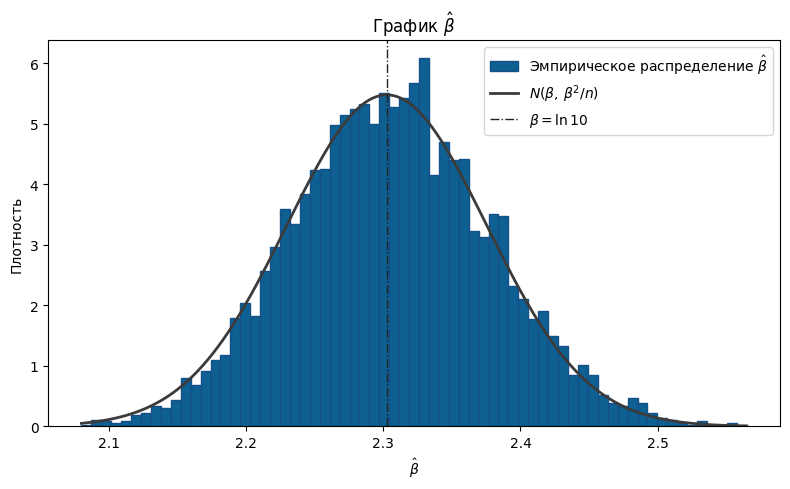

Эмпирическое среднее = 2.3064 (истинное 2.3026)
Эмпирическое std = 0.0722 (в теории 0.0728)


In [16]:
# 2.3 Гистограмма ОМП beta_hat + нормальная плотность

# Сгенерируйте N_rep оценок beta_hat по выборкам размера n_sim из Exp(beta_true).
N_rep, n_sim = 5000, 1000
beta_true = np.log(10)

# вот тут многократко генерируем выборку, затем beta_hat = n_sim/sum
betas = np.empty(N_rep)
for i in range(N_rep):
    sample = rng.exponential(1/beta_true, n_sim)
    betas[i] = n_sim / sample.sum()

sigma = beta_true / np.sqrt(n_sim) # запишем асимптотическое приближение
grid = np.linspace(betas.min(), betas.max(), 520)

# а теперь график олелелелеле
plt.figure(figsize=(8, 5))
plt.hist(betas, bins=67, density=True, color='#0D6091', edgecolor='#155089', label=r'Эмпирическое распределение $\hat{\beta}$')
plt.plot(grid, stats.norm.pdf(grid, loc=beta_true, scale=sigma), '#3b3b3b', lw=2, label=r"$N(\beta,\,\beta^2/n)$")
plt.axvline(beta_true, color="#222222", ls="dashdot", lw=1, label=r"$\beta=\ln 10$")
plt.xlabel(r"$\hat\beta$")
plt.ylabel("Плотность")
plt.title(r"График $\hat{\beta}$")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Эмпирическое среднее = {betas.mean():.4f} (истинное {beta_true:.4f})")
print(f"Эмпирическое std = {betas.std():.4f} (в теории {sigma:.4f})")


## Доверительные интервалы для $b$: асимптотический vs точный

Асимптотический интервал строится из нормальной аппроксимации $\hat\beta$; точный — из того факта, что $\beta S \sim \mathrm{Gamma}(n, 1)$ (сумма экспоненциальных величин — точная пивотальная статистика).

In [17]:
# 2.4 Асимптотический доверительный интервал

def ci_b_asympt(beta_hat, n, alpha=0.05):
    z = stats.norm.ppf(1 - alpha/2)
    lo_beta = beta_hat - z * (beta_hat / np.sqrt(n)) #se(beta_hat) = beta_hat/sqrt(n)
    hi_beta = beta_hat + z * (beta_hat / np.sqrt(n))
    res, ress = lo_beta / np.log(10), hi_beta / np.log(10)
    return res, ress


In [18]:
# 2.5 Точный доверительный интервал

def ci_b_exact(n, S, alpha=0.05):
    lo_beta = stats.chi2.ppf(alpha/2, 2*n) / (2*S)
    hi_beta = stats.chi2.ppf(1 - alpha/2, 2*n) / (2*S)
    res, ress = lo_beta / np.log(10), hi_beta / np.log(10)
    return res, ress


In [19]:
ALPHA = 0.05
for name, fn in [("Точный ДИ", lambda: ci_b_exact(n, S, ALPHA)),
                 ("Асимптотический ДИ", lambda: ci_b_asympt(beta_hat, n, ALPHA))]:
    lo, hi = fn()
    print(f"  {name:14s} b ∈ [{lo:.4f}, {hi:.4f}]  ширина {hi-lo:.4f}")


  Точный ДИ      b ∈ [0.9761, 1.0134]  ширина 0.0374
  Асимптотический ДИ b ∈ [0.9760, 1.0133]  ширина 0.0374


При $n \sim 10^4$ оба интервала практически совпадают — асимптотика уже вышла на режим. Различия проявляются на малых $n$ (см. проверку покрытия ниже).

## Порог полноты $M_c$: когда асимптотическая нормальность ломается

ОМП для $M_c$ — минимум выборки $M_{(1)}$. Но $M_{(1)} - M_c \sim \mathrm{Exp}(n\beta)$: распределение ошибки экспоненциальное при любом $n$, асимптотической нормальности нет, и оценка смещена вправо.

In [20]:
def mle_M_c(x):
  return x.min() #ровно то же самое, что и написали сверху


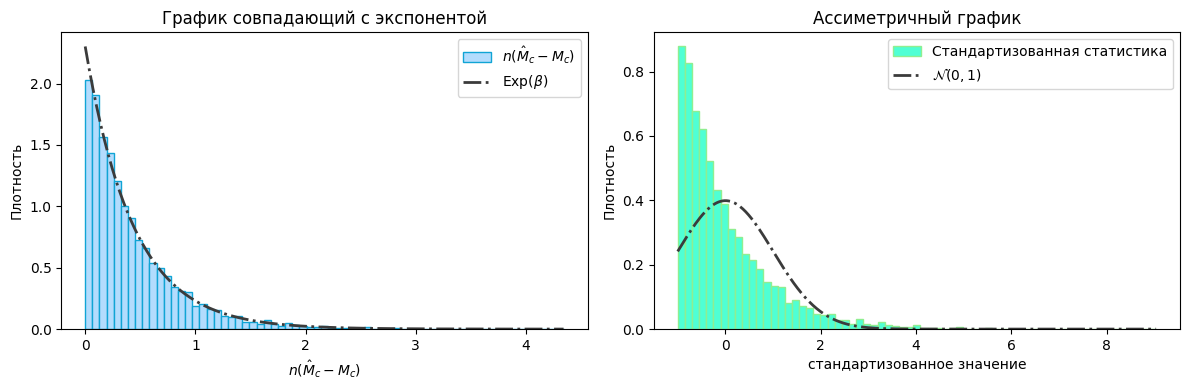

In [22]:
# 3.3 Гистограмма статистики n*(hat M_c - M_c): экспонента, а НЕ нормаль
N_rep, n_sim = 5000, 100
Mc_true, beta_true = 1.0, np.log(10)

shifts = np.empty(N_rep)
for i in range(N_rep):
    sample = Mc_true + rng.exponential(1/beta_true, n_sim)
    shifts[i] = n_sim * (sample.min() - Mc_true)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# слева график это сравнение статистики и Exp(beta)
grid = np.linspace(0, shifts.max(), 500)
ax[0].hist(shifts, bins=67, density=True, color="#b3dcfd", edgecolor="#10a4d5", label=r"$n(\hat{M}_c - M_c)$")
ax[0].plot(grid, stats.expon.pdf(grid, scale=1/beta_true), "#3b3b3b", ls="dashdot", lw=2, label=r"$\mathrm{Exp}(\beta)$")
ax[0].set_xlabel(r"$n(\hat{M}_c - M_c)$")
ax[0].set_ylabel("Плотность")
ax[0].set_title("График совпадающий с экспонентой")
ax[0].legend()

# справа график это сравнение стандартизованной статистики и N(0,1)
z = (shifts - shifts.mean()) / shifts.std()
grid2 = np.linspace(z.min(), z.max(), 500)
ax[1].hist(z, bins=67, density=True, color="#4FFFD4", edgecolor="lightgreen", label="Стандартизованная статистика")
ax[1].plot(grid2, stats.norm.pdf(grid2), "#3b3b3b", ls="dashdot", lw=2, label=r"$\mathcal{N}(0,1)$")
ax[1].set_xlabel("стандартизованное значение")
ax[1].set_ylabel("Плотность")
ax[1].set_title("Ассиметричный график")
ax[1].legend()

plt.tight_layout()
plt.show()


Симметричный «асимптотический» интервал вокруг $M_{(1)}$ здесь концептуально некорректен: он симметричен вокруг оценки, которая почти наверное **больше** истинного $M_c$, и регулярно накрывает логически невозможные значения $M_c > M_{(1)}$. Корректная альтернатива — точный односторонний интервал из экспоненциальной пивотальной статистики.

In [23]:
# 3.4 Асимптотический ДИ
def ci_mc_asympt(mags, beta_known, alpha=0.05):
    n = len(mags)
    M1 = mags.min()
    z = stats.norm.ppf(1 - alpha/2)
    se = 1.0 / (n * beta_known) #sd экспоненты Exp(n*beta)
    return M1 - z*se, M1 + z*se

ci_mc_naive_asympt = ci_mc_asympt #на будущее

M1 = mags.min()
mc_asympt = ci_mc_asympt(mags, beta_hat, ALPHA)

print(f"M_(1) = {M1:.3f}\n")
print(f"Асимптотический ДИ: M_c ∈ [{mc_asympt[0]:.4f}, {mc_asympt[1]:.4f}]")
print(f"\nВерхняя граница асимптотического = {mc_asympt[1]:.4f} > M_(1) = {M1:.4f}?  "
      f"{mc_asympt[1] > M1}  ← но M_c > M_(1) НЕВОЗМОЖНО!")


M_(1) = 1.000

Асимптотический ДИ: M_c ∈ [0.9999, 1.0001]

Верхняя граница асимптотического = 1.0001 > M_(1) = 1.0000?  True  ← но M_c > M_(1) НЕВОЗМОЖНО!


In [24]:
# 3.5 Точный односторонний ДИ для M_c при известном beta

def ci_mc_exact(mags, beta_known, alpha=0.05):
    n = len(mags)
    M1 = mags.min()
    lo = M1 - stats.chi2.ppf(1 - alpha, 2) / (2 * n * beta_known)
    return lo, M1


## Пуассоновская интенсивность потока событий

In [25]:
# Подсчёт событий по суткам

daily = df.set_index("time").resample("1D").size()
T = len(daily); S_pois = int(daily.sum()); lam_hat = S_pois / T
print(f"T = {T} суток, S = {S_pois} событий, lambda_hat = {lam_hat:.3f}")


T = 365 суток, S = 10894 событий, lambda_hat = 29.847


In [26]:
def mle_lambda(x):
  return x.mean()


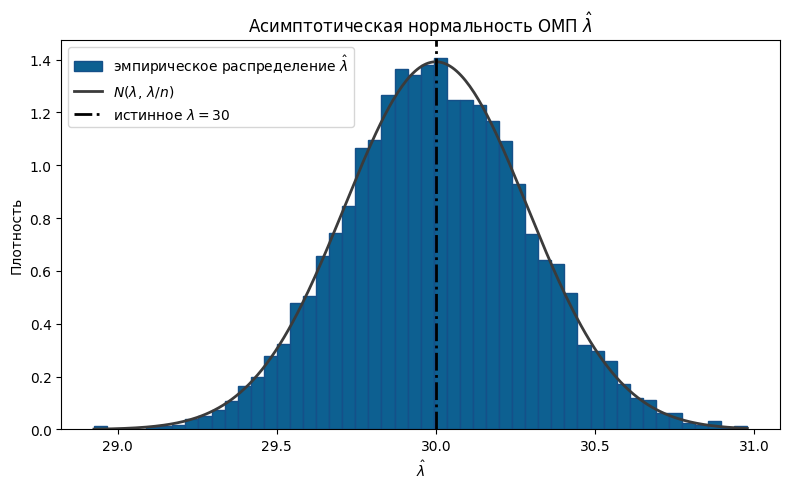

Эмпирическое среднее = 30.002 (истинное 30.0)
Эмпирическое std = 0.2880 (в теории 0.2867)


In [27]:
# Гистограмма ОМП lambda_hat + нормальная плотность
# Сгенерируйте N_rep оценок lambda_hat по выборкам размера n_sim из Pois(lambda).

N_rep = 8000
lam_true = 30.0           #
n_sim = len(daily)        # столько же суток, сколько в реальных данных

#считаем вот тут асимптотическую дисперсию: Var(lambda_hat) = lambda/n  =>  asy_var = lam_true/n_sim
asy_var = lam_true / n_sim
sigma = np.sqrt(asy_var)
lams = np.empty(N_rep)
for i in range(N_rep):
    sample = rng.poisson(lam_true, n_sim)
    lams[i] = sample.mean()
grid = np.linspace(lams.min(), lams.max(), 300)

#график ляляляля
plt.figure(figsize=(8, 5))
plt.hist(lams, bins=50, density=True, color='#0D6091', edgecolor='#155089', label=r'эмпирическое распределение $\hat{\lambda}$')
plt.plot(grid, stats.norm.pdf(grid, loc=lam_true, scale=sigma), '#3b3b3b', lw=2, label=r'$N(\lambda,\,\lambda/n)$')
plt.axvline(lam_true, color='black', ls='dashdot', lw=2, label=r'истинное $\lambda=30$')
plt.xlabel(r'$\hat{\lambda}$')
plt.ylabel('Плотность')
plt.title(r'Асимптотическая нормальность ОМП $\hat{\lambda}$')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Эмпирическое среднее = {lams.mean():.3f} (истинное {lam_true})")
print(f"Эмпирическое std = {lams.std():.4f} (в теории {sigma:.4f})")


In [28]:
#  Асимптотический ДИ для lambda
def ci_pois_asympt(S, T, alpha=0.05):
    lam = S / T
    z = stats.norm.ppf(1 - alpha/2)
    se = np.sqrt(lam / T)
    res, ress = lam - z * se, lam + z * se
    return res, ress

lo, hi = ci_pois_asympt(S_pois, T, ALPHA)
print(f"Асимптотический ДИ:  λ ∈ [{lo:.3f}, {hi:.3f}]   ширина {hi-lo:.3f}")


Асимптотический ДИ:  λ ∈ [29.286, 30.407]   ширина 1.121


## Проверка покрытия методом Монте-Карло

In [29]:
# 5.1
def coverage(build_ci, sampler, theta_true, M=3000, n=50, seed=0):

    '''build_ci(sample) -> (lo, hi); sampler(n, rng) -> sample.
       Возвращает (доля_накрытий, средняя_ширина).'''

    rng = np.random.default_rng(seed)
    hit = 0; width = 0.0

    for _ in range(M):
        smp = sampler(n, rng)
        lo, hi = build_ci(smp)
        if lo <= theta_true <= hi:
            hit += 1
        width += hi - lo

    return hit/M, width/M


In [30]:
# Покрытие для b-value

MC_TRUE, B_TRUE = 1.0, 1.0; BETA_TRUE = B_TRUE * np.log(10)
exp_sampler = lambda n, rng: MC_TRUE + rng.exponential(1/BETA_TRUE, n)

rows = []
for nn in [15, 30, 100, 500]:

    for name, mk in [

        ("точный", lambda smp: ci_b_exact(len(smp), (smp - MC_TRUE).sum())),
        ("асимптотический",  lambda smp: ci_b_asympt(len(smp)/(smp - MC_TRUE).sum(), len(smp)))   ]:

        cov, w = coverage(mk, exp_sampler, B_TRUE, M=2000, n=nn, seed=1)
        rows.append((nn, name, round(cov, 3)))

print("Покрытие для b-value:")
print(pd.DataFrame(rows, columns=["n","метод","покрытие"]).pivot(index="метод", columns="n", values="покрытие"))


Покрытие для b-value:
n                  15     30     100    500
метод                                      
асимптотический  0.955  0.952  0.945  0.953
точный           0.948  0.953  0.946  0.954


In [32]:
# Покрытие для M_c

rows_mc = []

for nn in [15, 30, 100, 500]:

    for name, mk in [

        ("точный",        lambda smp: ci_mc_exact(smp, BETA_TRUE)),
        ("асимптотический",  lambda smp: ci_mc_naive_asympt(smp, BETA_TRUE)),
    ]:

        cov, w = coverage(mk, exp_sampler, MC_TRUE, M=2000, n=nn, seed=2)
        rows_mc.append((nn, name, round(cov, 3), round(w, 4)))

mc_tab = pd.DataFrame(rows_mc, columns=["n","метод","покрытие","ширина"])

print("Покрытие для M_c:")
print(mc_tab.pivot(index="метод", columns="n", values="покрытие"))
print("\nСредняя ширина (внимание на масштаб!):")
print(mc_tab.pivot(index="метод", columns="n", values="ширина"))


Покрытие для M_c:
n                  15     30     100    500
метод                                      
асимптотический  0.856  0.864  0.860  0.855
точный           0.958  0.951  0.952  0.947

Средняя ширина (внимание на масштаб!):
n                   15      30     100     500
метод                                         
асимптотический  0.1135  0.0567  0.017  0.0034
точный           0.0867  0.0434  0.013  0.0026


In [33]:
# Диагностика: в КАКОЙ ДОЛЕ моделирований асимптотический интервал содержит
# логически невозможные значения (M_c > min(X))?

M_diag = 2000; n_diag = 50; impossible = 0

for _ in range(M_diag):

    smp = exp_sampler(n_diag, rng)
    lo, hi = ci_mc_naive_asympt(smp, BETA_TRUE)

    if hi > smp.min(): impossible += 1

print(f"Доля случаев, когда асимптотический интервал содержит области M_c > min(X): {impossible/M_diag:.3f}")
print("Это значит, что половина каждого асимптотического интервала находится в НЕВОЗМОЖНОЙ области.")


Доля случаев, когда асимптотический интервал содержит области M_c > min(X): 1.000
Это значит, что половина каждого асимптотического интервала находится в НЕВОЗМОЖНОЙ области.


## Выводы

- Для $b$-value асимптотический и точный интервалы согласуются при больших $n$; на малых выборках точный (гамма-пивот) держит заявленное покрытие лучше.
- Для $M_c$ асимптотическая нормальность ОМП не выполняется ни при каком $n$: ошибка распределена экспоненциально. Симметричный интервал систематически недокрывает и захватывает невозможные значения; точный односторонний интервал держит покрытие ровно.
- Монте-Карло проверка покрытия — простой и универсальный способ поймать некорректный интервал до того, как он попадёт в продакшн-отчёт.